In [11]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# ==========================================
# 1. Load Dataset
# ==========================================

X = np.load("final_data_gesture.npy")
y = np.load("final_labels_gesture.npy")

print("Original X shape:", X.shape)
print("Original y shape:", y.shape)

# ==========================================
# 2. Normalize (important for stability)
# ==========================================

X = X.astype("float32")

# landmarks already 0–1 but we ensure type consistency
X = X / 1.0

# ==========================================
# 3. One-Hot Encode Labels
# ==========================================

num_classes = 5
y = to_categorical(y, num_classes)

# ==========================================
# 4. Train-Test Split (Stratified)
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ==========================================
# 5. Build SMALLER Conv1D + GRU Model
# (Better for small dataset)
# ==========================================

model = Sequential()

model.add(Conv1D(32, 3, activation='relu', input_shape=(30, 42)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Conv1D(64, 3, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(GRU(64))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dense(5, activation='softmax'))

# ==========================================
# 6. Compile Model
# ==========================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==========================================
# 7. Early Stopping (less aggressive)
# ==========================================

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True
)

# ==========================================
# 8. Train Model
# ==========================================

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

# ==========================================
# 9. Evaluate
# ==========================================

loss, accuracy = model.evaluate(X_test, y_test)
print("\nFinal Test Accuracy:", accuracy)

# ==========================================
# 10. Save Model
# ==========================================

model.save("gesture_model.h5")
print("✅ Model saved as new_gesture_model.h5")


Original X shape: (1250, 30, 42)
Original y shape: (1250,)
Train shape: (1000, 30, 42)
Test shape: (250, 30, 42)
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_2 (Conv1D)           (None, 28, 32)            4064      
                                                                 
 batch_normalization_2 (Bat  (None, 28, 32)            128       
 chNormalization)                                                
                                                                 
 dropout_3 (Dropout)         (None, 28, 32)            0         
                                                                 
 conv1d_3 (Conv1D)           (None, 26, 64)            6208      
                                                                 
 batch_normalization_3 (Bat  (None, 26, 64)            256       
 chNormalization)                                                
       

C:\Users\narth\gesture_env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [13]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define class names 
class_names = ["left", "right", "forward", "Backward", "stop"]

# Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Accuracy
print("Test Accuracy:", accuracy_score(y_true, y_pred))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


8/8 [==============================] - 0s 5ms/step
Test Accuracy: 0.964

Classification Report:

              precision    recall  f1-score   support

        left       1.00      0.92      0.96        50
       right       1.00      0.98      0.99        50
     forward       0.91      1.00      0.95        50
    Backward       1.00      0.92      0.96        50
        stop       0.93      1.00      0.96        50

    accuracy                           0.96       250
   macro avg       0.97      0.96      0.96       250
weighted avg       0.97      0.96      0.96       250



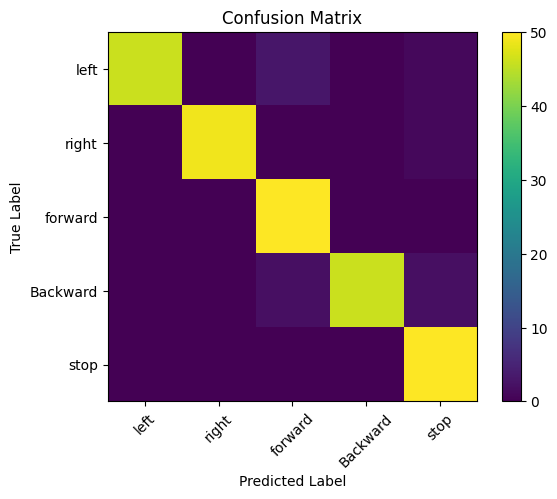

In [19]:
import matplotlib.pyplot as plt
cm = confusion_matrix(y_true, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()
plt.show()


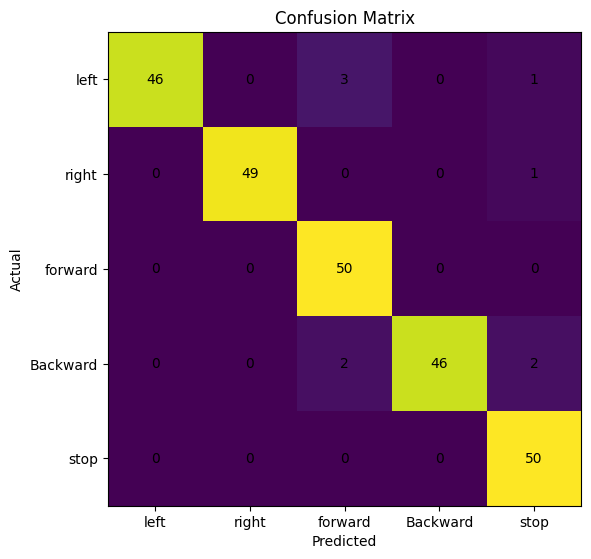

In [21]:
plt.figure(figsize=(6,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.tight_layout()
plt.show()


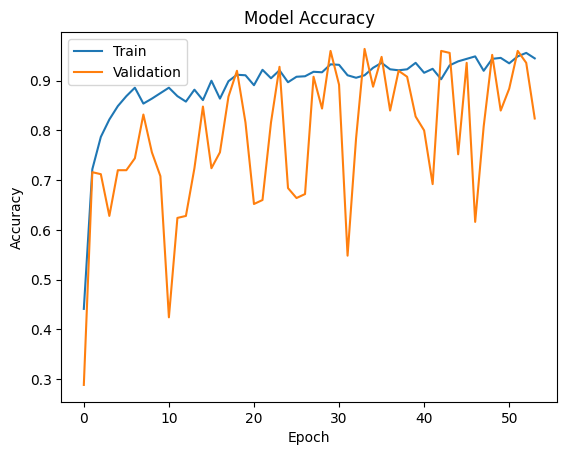

In [23]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()


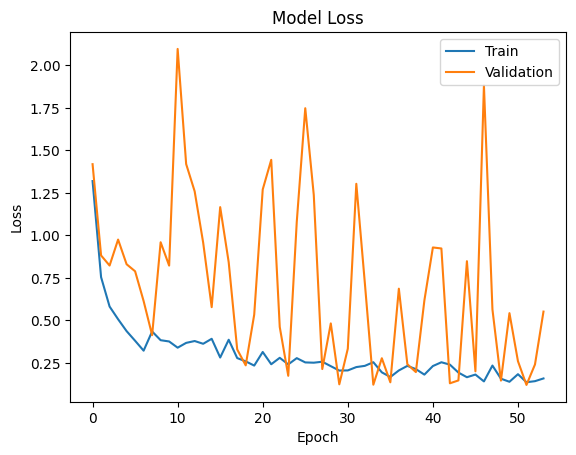

In [25]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()



In [27]:
import cv2
import numpy as np
import mediapipe as mp
from tensorflow.keras.models import load_model
from collections import deque, Counter

# ==============================
# 1. Load GRU Gesture Model
# ==============================

model = load_model("gesture_model.h5")

# ==============================
# 2. MediaPipe Setup
# ==============================

mp_hands = mp.solutions.hands
hands = mp_hands.Hands(max_num_hands=1)

# ==============================
# 3. Labels
# ==============================

gestures = {
    0: "LEFT",
    1: "RIGHT",
    2: "FORWARD",
    3: "BACKWARD",
    4: "STOP"
}

# ==============================
# 4. Buffers
# ==============================

sequence_buffer = []
prediction_buffer = deque(maxlen=5)

SEQUENCE_LENGTH = 30
CONFIDENCE_THRESHOLD = 0.85

# ==============================
# 5. Extract Landmarks
# ==============================

def extract_landmarks(frame):

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(frame_rgb)

    if results.multi_hand_landmarks:

        hand = results.multi_hand_landmarks[0]
        landmarks = []

        for lm in hand.landmark:
            landmarks.extend([lm.x, lm.y])

        return landmarks

    return None


# ==============================
# 6. Start Camera
# ==============================

cap = cv2.VideoCapture(0)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    landmarks = extract_landmarks(frame)

    if landmarks is not None:

        sequence_buffer.append(landmarks)

        if len(sequence_buffer) == SEQUENCE_LENGTH:

            input_data = np.expand_dims(sequence_buffer, axis=0)

            prediction = model.predict(input_data, verbose=0)[0]

            label = np.argmax(prediction)
            confidence = np.max(prediction)

            if confidence >= CONFIDENCE_THRESHOLD:
                prediction_buffer.append(label)

            sequence_buffer.pop(0)

    # ==============================
    # Majority Voting
    # ==============================

    final_command = ""

    if len(prediction_buffer) == 5:

        most_common = Counter(prediction_buffer).most_common(1)[0][0]
        final_command = gestures[most_common]

    # ==============================
    # Display
    # ==============================

    if final_command != "":

        cv2.putText(
            frame,
            f"COMMAND: {final_command}",
            (10, 50),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 0),
            3
        )

    cv2.imshow("Final Wheelchair Control", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break


cap.release()
cv2.destroyAllWindows()
hands.close()

KeyboardInterrupt: 

In [5]:
import tensorflow as tf

In [13]:
import tensorflow as tf

# Load model
model = tf.keras.models.load_model("gesture_model.h5")

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Important Fix
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

converter._experimental_lower_tensor_list_ops = False

# Convert
tflite_model = converter.convert()

# Save
with open("gesture_model_final.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ TFLite model created successfully")

INFO:tensorflow:Assets written to: C:\Users\narth\AppData\Local\Temp\tmp6_k_oilk\assets


INFO:tensorflow:Assets written to: C:\Users\narth\AppData\Local\Temp\tmp6_k_oilk\assets


✅ TFLite model created successfully
